# Классификация умственной нагрузки по сигналам ЭЭГ с помощью CNN

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек](#1.1.)
<br>[1.2. Функции обработки сигналов ЭЭГ](#1.2.)
<br>[1.3. Пространственная модель головы и координаты электродов в анализе ЭЭГ](#1.3.)
<br>[1.4. Визуальный контроль качества данных](#1.4.)
<br>[<b>Шаг 2. Подготовка данных</b>](#2)
<br>[2.1. Сборка датасета топокарт](#2.1.)
<br>[2.2. Разделение на тестовую и обучающую выборки](#2.2.)
<br>[<b>Шаг 3. Создание базовой модели</b>](#3)
<br>[3.1. Построение базовой модели](#3.1.)
<br>[3.2. Обучение базовой модели](#3.2.)
<br>[3.3. Визуализация результатов](#3.3.)
<br>[3.4. Метрики оценки качества базовой модели](#3.4.)
<br>[<b>Шаг 4. Создание улучшенной модели</b>](#4)
<br>[4.1. Методы борьбы с переобучением](#4.1.)
<br>[4.2. Архитектура улучшенной модели](#4.2.)
<br>[4.3. Обучение улучшенной модели](#4.3.)
<br>[4.4. Визуализация результатов улучшенной модели](#4.4.)
<br>[4.5. Метрики оценки качества улучшенной модели](#4.5.)
<br>[4.6. Предсказание на случайном файле (инференс)](#4.6.)
<br>[<b>Вывод</b>](#5)
<br>[<b>Источники и литература</b>](#6)

<a id=#descr_proj></a>
## Описание проекта

Электроэнцефалография (ЭЭГ) — это метод регистрации электрической активности головного мозга. В контексте нейроэргономики и интерфейсов "мозг-компьютер" (BCI) критически важной задачей является оценка умственной нагрузки (mental workload). Способность системы в реальном времени определять, справляется ли оператор с задачей или находится в состоянии когнитивного перегруза, позволяет адаптировать сложность задачи или инициировать отдых.
Традиционные методы анализа ЭЭГ опираются на ручное извлечение признаков (статистические метрики, спектральная мощность). Однако пространственно-временные паттерны активности мозга обладают высокой нелинейностью. Применение свёрточных нейронных сетей (CNN) позволяет перевести задачу классификации временных рядов в задачу компьютерного зрения.
В данном проекте мы преобразуем многоканальные сигналы ЭЭГ в 2D-топографические карты (топокарты), где цветом кодируется спектральная мощность основных мозговых ритмов. Это позволяет CNN использовать свои мощные механизмы извлечения пространственных иерархий признаков для поиска скрытых паттернов, отличающих состояние решения знакомой задачи от решения новой, сложной задачи.
Постановка задачи: Разработать и обучить свёрточную нейронную сеть для бинарной классификации состояний мозга (Известный навык vs Неизвестный навык) на основе 2D-топокарт спектральной мощности ЭЭГ. Оценить качество базовой модели, выявить признаки переобучения и разработать улучшенную архитектуру с применением методов регуляризации.

<a id=descr_data></a>
## Описание данных

В обработке находятся записи ЭЭГ, сделанные с помощью 14-канальной потребительской гарнитуры (мы предполагаем использование популярной гарнитуры `Emotiv EPOC`).
Класс 1 (KS - Known Skill): Выполнение хорошо знакомого, автоматизированного задания (низкая/умеренная умственная нагрузка).
Класс 0 (US - Unknown Skill): Выполнение нового, сложного задания, требующего высокой концентрации и рабочей памяти (высокая умственная нагрузка).

**Специфика данных:** из всех спектральных ритмов для нас интерес представляют следующие три диапазона:
* Theta (4-8 Гц) — когнитивное напряжение, рабочая память.
* Alpha (8-12 Гц) — расслабление, ингибирование ненужных зон мозга (при нагрузке альфа-ритм десинхронизируется/подавляется).
* Beta (12-40 Гц) — активное бодрствование, концентрация, решение задач.

**Пространственное представление:** 14 каналов проецируются на 2D-плоскость (по системе 10-20) и интерполируются до изображений размером 28x28 пикселя.
<br>**Формат "изображения":** каждый "снимок" мозга имеет размер (28, 28, 3), где 3 канала — это мощности Theta, Alpha и Beta ритмов (аналог RGB в обычных изображениях).

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [1]:
from eeg_learn_functions import * # кастомная библиотека с готовыми функциями перевода числовых данныхе электродов в 2D-картинку путём интерполяции по координатам головы

import pandas as pd  # для работы с табличными данными
import numpy as np   # математические операции с длинными массивами числе (ЭЭГ - то и есть такой массив чисел, то есть напряжение в микровольтах через равные промежутки времени)  
from numpy import genfromtxt # функция из numpy, которая читает текстовый/CSV-файл и превращает его в numpy-массив для загрузки .csv файлов с записями ЭЭГ
import matplotlib.pyplot as plt # визуализация: графики, сырые сигналы, тепловые карты
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit  # разделение на обучающую и тестовую выборки
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score # метрики оценки качества
import scipy.stats as scs
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
import re
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical # one-hot encoding для превращения метки 0 в вектор [1, 0], а метки 1 в вектор [0, 1] потому что на выходе сети 2 нейрона (по числу классов)
from tensorflow.keras.models import Sequential # класс для построения свёрточной нейронной сети
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Activation, Flatten, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from IPython.display import display, HTML

# команда для вывода графиков в ячейках
%matplotlib inline

# настройка стиля и размера графиков
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (12, 12)

# расширение ширины контейнера Jupyter на весь экран
display(HTML("<style>.container { width:100% !important; }</style>"))

# настройки отображения pandas
pd.options.display.max_columns = None
pd.options.display.precision = 4

<a id=1.2.></a>
### 1.2. Функции обработки сигналов ЭЭГ

ЭЭГ записывает суммарное электрическое напряжение на поверхности головы. Это смесь колебаний разных частот. Нейрофизиологи договорились делить их на диапазоны:

|Наименование|Диапазон|Функционал|
|---|---|---|
|Delta|0–4 Гц|Глубокий сон без сновидений|
|Theta|4–8 Гц|Дремота, медитация, лёгкая сонливость, внутренняя концентрация|
|Alpha|8–12 Гц|Расслабленное бодрствование, закрытые глаза, «idle»-режим мозга|
|Beta|12–40 Гц|Активное мышление, решение задач, стресс, концентрация внимания|
|Gamma|>30 Гц|Высшие когнитивные функции, связывание информации из разных зон|

В лекции мы определяем только три кортежа `(нижняя_граница, верхняя_граница)` в Герцах:

    theta = (4, 8) — потом будем вычислять среднюю мощность сигнала в полосе 4–8 Гц.
    alpha = (8, 12) — средняя мощность в полосе 8–12 Гц.
    beta = (12, 40) — средняя мощность в полосе 12–40 Гц.

Delta и Gamma в комментариях упомянуты для полноты картины, но в данной задаче не используются, потому что Delta почти отсутствует при бодрствовании (а эксперимент на бодрствующих людях), а Gamma сильно загрязнена мышечными артефактами (моргание, сжатие челюстей) и требует более сложной фильтрации. Каждый кортеж — это просто пара чисел, которая потом передаётся в функцию для вырезания нужного куска спектра.

Библиотека для анализа EEG сигналов: https://github.com/pbashivan/EEGLearn

In [2]:
# кортежи ЭЭГ
# задаём границы тета-ритма (отвечает за сон, дремоту, эмоции)
theta_range = (4, 8)

# задаем границы альфа-ритма (отвечает за расслабление с закрытыми глазами)
alpha_range = (8, 12)

# задаем границы бета-ритма (отвечает за активное бодрствование, концентрацию)
beta_range = (12, 40)

Для перевода сырых временных рядов в "картинки" нам необходим конвейер: БПФ (FFT) -> вычисление мощности ритмов -> 2D-интерполяция.

In [3]:
# функция преобразования Фурье
def get_fft(snippet):                # сниппет - входные данные в виде фрагмента ЭЭГ-сигнала
    Fs = 128.0;                      # частота дискретизации = 128 Гц (128 отсчётов в секунду)
    snippet_time = len(snippet)/Fs   # расчёт общей длительности этого сниппета в секундах
    Ts = 1.0/Fs;                     # Вычисляет период дискретизациb: время между двумя соседними измерениями
    t = np.arange(0, snippet_time, Ts) # вектор времени в виде массива от нуля до snippet_time с интервалом Ts
    y = snippet
    n = len(y)                       # общее количество точек (отсчётов) в данном фрагменте сигнала
    k = np.arange(n)                 # индексы ячеек (бинов) будущего спектра
    T = n/Fs                         # по сути - копия переменной snippet_time, общая длительность сигнала в секундах
    frq = k/T                        # вычисление реальных частот в Гц для каждого бина спектра
    frq = frq[range(n//2)]           # отбрасываем вторую половину спектра, потому что для вещественных сигналов типа ЭЭГ спектр Фурье симметричен
    Y = np.fft.fft(y)/n              # переводим сигнал из временной плоскости в частотную с результатом в виде комплексного числ с нормированием амплитуды (деление на n)
    Y = Y[range(n//2)]               # согласовываем массив частот Y с ранее обрезанным массивом частот frq и ставляем только постоянную составляющую (0 Гц) и положительные частоты
    power = np.abs(Y) ** 2           # расчёт мощности в Дб
    power_db = 10 * np.log10(power + 1e-12)

    return frq, power_db                 # возвращает два массива: 1) массив частот в Гц (от 0 до 64); 2) массив амплитуд (модулей комплексных чисел) с указанием мощности каждой частоты в сигнале

In [4]:
# функция вычисления средней спектральной мощности по основным диапазонам ритмов ЭЭГ
def theta_alpha_beta_averages(f, Y):
    # отфильтровываем мощность Y только для частот из тета-диапазона и считаем среднее значение
    theta = Y[(f > theta_range[0]) & (f <= theta_range[1])].mean()
    # отфильтровываем мощность Y только для частот из альфа-диапазона и считаем среднее
    alpha = Y[(f > alpha_range[0]) & (f <= alpha_range[1])].mean()
    # отфильтровываем мощность Y только для частот из бета-диапазона и считаем среднее
    beta = Y[(f > beta_range[0]) & (f <= beta_range[1])].mean()
    
    # возвращаем три вычисленные средние мощности (тета, альфа, бета)
    return theta, alpha, beta

Непрерывный ЭЭГ-сигнал слишком длинный для анализа целиком, поэтому его делят на короткие кусочки (обычно от 1 до 5 секунд). Чтобы не терять важную информацию на границах этих кусочков и чтобы получить более плавную картину изменений во времени, мы сделаем эти фрагменты перекрывающимися (overlap). Так, если длина фрейма 2 секунды, а overlap = 0.5 (50%), то первый фрейм будет с 0 по 2 секунду, второй — с 1 по 3 секунду, третий — с 2 по 4 и т.д. Эта функция математически рассчитывает эти границы в виде индексов массива.

In [5]:
# функция подготовки индексов для нарезки непрерывного ЭЭГ-сигнала на короткие отрезки сэмплов 
def make_steps(samples, frame_duration, overlap):
    '''
    Функция рассчитывает границы (индексы начала и конца) для нарезки 
    непрерывного ЭЭГ сигнала на перекрывающиеся временные окна (фреймы).
    
    in:
    samples - количество сэмплов в одной сессии
    frame_duration - длительность фрейма в секундах 
    overlap - часть накладываемого фрейма в диапазоне (0,1)
    
    out: list of tuple ranges
    '''
    Fs = 128 # задаём частоту дискретизации (sampling rate) ЭЭГ сигнала — 128 Гц
    i = 0 # начальный индекс (с него начинается самый первый фрейм)
    intervals = [] # список, в который будем сохранять пары индексов (начало, конец) для каждого фрейма
    samples_per_frame = Fs * frame_duration # вычисляем, сколько отсчётов (сэмплов) должно быть в одном фрейме заданной длительности
    
    while i + samples_per_frame <= samples: # цикл продолжается, пока конец текущего фрейма не выйдет за пределы всего сигнала
        
        intervals.append((i, i + samples_per_frame))   # запоминаем начальный и конечный индексы текущего фрейма
        
        # вычисляем стартовую позицию для следующего фрейма
        # мы сдвигаемся на длину фрейма, но вычитаем из этого сдвига величину перекрытия (overlap),
        # чтобы соседние фреймы частично накладывались друг на друга
        i = i + samples_per_frame - int(samples_per_frame * overlap)
        
    # возвращаем список кортежей с индексами, по которым потом можно будет нарезать массив с ЭЭГ
    return intervals

Следующая функция объединяет предыдущие шаги: мы нарезаем многоканальный ЭЭГ-сигнал на окна, считаем для каждого окна спектр и вычисляем мощности основных ритмов. На выходе получается трехмерный массив (время × каналы × ритмы).

In [6]:
# вычисление средней мощности тета, альфа, бета ритмов в каждом фрейме многоканальной ЭЭГ     
def make_frames(df, frame_duration, overlap):
    '''
    in: датафрейм или массив со всеми каналами, длительностью фрейма в секундах
    out: массив средних значений theta, alpha, beta для каждой пробы в каждый момент времени
        размерность: (n-frames, m-probes, k-brainwave bands)
    '''
    Fs = 128.0                               # частота дискретизации сигнала (128 Гц)
    frame_length = Fs * frame_duration       # вычисляем длину фрейма в количестве отсчетов (сэмплов)
    frames = []                              # пустой список для накопления итоговых результатов по всем фреймам
    steps = make_steps(len(df), frame_duration, overlap) # вызываем предыдущую функцию, чтобы получить список границ (индексов) для нарезки
    
    for i, _ in enumerate(steps):     # перебираем все полученные временные окна (фреймы) по их индексам
        
        frame = []                    # временный список для хранения мощностей ритмов по всем каналам для ТЕКУЩЕГО фрейма

        if i == 0:                    # пропускаем самый первый фрейм с индексом 0, чтобы избежать краевых эффектов БПФ или использовать его как базу
            continue
        else:
            for channel in df.columns:   # перебираем каждый канал (электрод) в датафрейме
                
                snippet = np.array(df.loc[steps[i][0]:steps[i][1], int(channel)])   # извлекаем кусочек сигнала (снэпшот) для текущего канала (электрода) и текущего временного окна
                f, Y = get_fft(snippet)                                             # считаем быстрое преобразование Фурье: получаем массив частот (f) и мощностей (Y)
                theta, alpha, beta = theta_alpha_beta_averages(f, Y)                # считаем среднюю мощность для трех основных ритмов
                frame.append([theta, alpha, beta])                                  # добавляем три вычисленные мощности в список текущего фрейма
        
        frames.append(frame) # добавляем в общий список все обработанные каналы
        
    # превращаем вложенный список в трехмерный numpy-массив и возвращаем
    # размерность: (количество фреймов, количество каналов, 3 ритма)
    return np.array(frames)

### 1.3. Пространственная модель головы и координаты электродов в анализе ЭЭГ

Сформируем пары чисел, которые представляют собой двумерную пространственную модель расположения электродов на поверхности головы. В контексте анализа электроэнцефалограммы (ЭЭГ) эти данные играют роль фундаментального «якоря», который связывает абстрактные числовые значения сигналов с их реальным анатомическим положением. Без этой пространственной привязки мы бы имели лишь набор чисел, отражающих активность каналов, но не могли бы понять, в какой именно зоне мозга эта активность сосредоточена.

*Соответствие зонам мозга (международная система 10-20)*

| Y-координата | Зона мозга | Электрод <br>левого полушария | Электрод <br>правого полушария | Функциональная роль |
|:---:|---|---|---|---|
| **4.0** | Лобная (Frontal) | AF3 | AF4 | Внимание, принятие решений |
| **3.0** | Лобно-центральная | F3, F7 | F4, F8 | Рабочая память, речь, эмоции |
| **2.0** | Центральная (Central) | FC5 | FC6 | Моторика, соматосенсорика |
| **1.0** | Височная (Temporal) | T7 | T8 | Слух, обработка звуков |
| **-2.0** | Теменная (Parietal) | P7 | P8 | Пространственное восприятие |
| **-3.0** | Затылочная (Occipital) | O1 | O2 | Обработка визуальной информации |

**Итого:** 7 электродов слева + 7 электродов справа = **14 каналов**

Чтобы правильно интерпретировать эти координаты, необходимо представить себе вид на голову человека строго сверху. Каждая пара чисел в списке — это декартовы координаты (X, Y) конкретного электрода на этой условной плоскости. Горизонтальная ось X отвечает за латеральное, или лево-правое, распределение: отрицательные значения указывают на левое полушарие, а положительные — на правое. Вертикальная ось Y отражает передне-заднее направление, то есть удаление от лобных долей к затылочным. Чем больше положительное значение Y, тем ближе электрод ко лбу; чем ближе значение к отрицательным, тем ниже к затылку опускается датчик. Точка (0, 0) в этой системе координат концептуально соответствует макушке (вертексу), центру головы. Строгая симметрия этих пар относительно оси X подчеркивает парность структур мозга, позволяя в дальнейшем сравнивать активность левого и правого полушарий.

Главная практическая цель создания этого списка — обеспечение возможности построения топографических карт мозга (топокарт или topoplots). В коде, который следует за этим определением, алгоритм берёт вычисленные значения мощности мозговых ритмов (тета, альфа, бета) для каждого из 14 каналов в конкретный момент времени. Зная координаты каждого канала из списка `locs_2d`, программа размещает эти 14 значений на двумерной плоскости. Однако мозг — это непрерывная структура, а не 14 изолированных точек. Чтобы визуализация была наглядной, алгоритм применяет математическую интерполяцию. Он «размывает» значения между известными координатами, создавая плавный цветовой градиент. В результате на экране появляется интуитивно понятная «тепловая карта» головы, где цветом показано распределение нейронной активности по всей поверхности скальпа, а не только в местах крепления датчиков.

Важно понимать, что приведенные ниже в списке числа — это не реальные физические координаты в миллиметрах, снятые с трехмерной модели головы конкретного человека. Это нормализованные, схематичные координаты, отражающие логику международной системы наложения электродов «10-20», адаптированную под конфигурацию 14-канальных потребительских ЭЭГ-гарнитур, таких как `Emotiv EPOC` или `EPOC+`. 

В клинической нейровизуализации, где также используются шапочки на 64, 128 или более каналов, применяются точные трёхмерные координаты, учитывающие индивидуальную форму черепа. Однако для 14-канальных гарнитур, которые имеют жёстко фиксированное расположение датчиков, использование упрощенных двумерных координат является общепринятым стандартом. Такой подход значительно упрощает и ускоряет вычисления при отрисовке графиков, сохраняя при этом полную анатомическую и функциональную достоверность отображаемой картины. Таким образом, список `locs_2d` послужит идеальным мостом между сырыми цифровыми данными ЭЭГ и их качественной, наглядной визуализацией.

In [7]:
# стандартная 14-канальная ЭЭГ-гарнитура
locs_2d = [(-2.0,4.0),
           (2.0,4.0),
           (-1.0,3.0),
           (1.0,3.0),
           (-3.0,3.0),
           (3.0,3.0),
           (-2.0,2.0),
           (2.0,2.0),
           (-2.0,-2.0),
           (2.0,-2.0),
           (-4.0,1.0),
           (4.0,1.0),
           (-1.0,-3.0),
           (1.0,-3.0)]

In [8]:
# пайплайн подготовки данных для свёрточной нейронной сети
def make_data_pipeline(file_names, labels, image_size, frame_duration, overlap):
    '''
    Функция загружает файлы ЭЭГ, разбивает их на фреймы, вычисляет мощности ритмов 
    и превращает эти данные в двумерные изображения (топокарты) для обучения нейросети.
    '''
    Fs = 128.0                                   # частота сэмплирования
    frame_length = Fs * frame_duration           # длина фрейма в отсчётах
    print('Генерирование обучающей выборки...')
    
    # создаём пустой список для ID
    subject_ids = [] 
    
    # цикл по каждому файлу (наблюдаемому пациенту)
    for i, file in enumerate(file_names):
        print ('Сессия обработки: ', file, '. (', i+1, ' of ', len(file_names), ')')  

        match = re.search(r'ML(\d+)_', file)                    # извлекаем ID пациента из имени файла
        true_subject_id = match.group(1) if match else str(i)
        data = genfromtxt(file, delimiter=',').T 
        df = pd.DataFrame(data) 
        df = clean_eeg(df)  
        X_0 = make_frames(df, frame_duration, overlap)  
        X_1 = X_0.reshape(len(X_0), 14*3)  
        images = gen_images(np.array(locs_2d), X_1, image_size, normalize=False) 
        images = np.swapaxes(images, 1, 3)    
        subject_ids.extend([true_subject_id] * len(images))      # запоминаем ID пациента
               
        print(len(images), ' фреймов, сгенерированных с меткой ', labels[i], '.\n')  
        
        if i == 0:
            X = images
            y = np.ones(len(images)) * labels[0]
        else:
            X = np.concatenate((X, images), axis=0)
            y = np.concatenate((y, np.ones(len(images)) * labels[i]), axis=0)
            
    # возвращаем итоговый набор данных: картинки (X), метки (y) и ID пациентов (subject_ids)
    return X, np.array(y), np.array(subject_ids)

In [9]:
def clean_eeg(df, fs=128.0, lowcut=1.0, highcut=40.0, order=4):
    """
    Полосовая фильтрация + удаление артефактного участка
    для применения к каждому файлу отдельно внутри пайплайна.
    """
    # полосовой фильтр 1–40 Гц, который убирает дрейф и мышечный шум
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    filtered = filtfilt(b, a, df.values, axis=0)
    df_clean = pd.DataFrame(filtered, columns=df.columns)
    
    # вырезаем глобальный артефакт (отсчёты 6000–6500), если он попадает в диапазон данного файла
    artifact_start, artifact_end = 6000, 6500
    if artifact_start < len(df_clean):
        end = min(artifact_end, len(df_clean))
        df_clean = pd.concat([df_clean.iloc[:artifact_start], df_clean.iloc[end:]]).reset_index(drop=True)
    
    return df_clean

In [10]:
# загружаем данные
data = genfromtxt('EEG_data/ML101_KS.csv', delimiter=',').T
df = pd.DataFrame(data)

# выводим на ознакомление
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-78.03,-75.99,-88.74,-87.21,-53.04,-64.77,-69.87,-80.07,-72.42,-68.85,-77.01,-69.87,-102.00,-116.79
1,-79.56,-77.01,-92.82,-93.84,-54.57,-65.79,-82.62,-93.33,-71.91,-78.03,-76.50,-59.67,-97.41,-121.38
2,-77.52,-77.01,-92.31,-89.76,-78.54,-59.16,-76.50,-75.99,-84.66,-61.71,-80.58,-71.91,-102.00,-139.23
3,-78.54,-73.44,-87.21,-81.60,-67.83,-59.16,-74.46,-67.83,-85.17,-55.08,-83.64,-83.13,-99.96,-136.17
4,-74.46,-64.26,-81.09,-75.48,-57.63,-62.73,-75.48,-75.48,-73.44,-62.73,-84.15,-79.56,-92.31,-128.52


In [11]:
# описательная статистика
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000,15104.0000
mean,-74.5237,-74.5262,-75.2090,-84.5480,-74.6888,-74.4620,-74.7108,-75.0444,-74.7568,-73.7301,-74.6366,-73.9806,-74.8771,-74.5024
std,22.7225,18.4686,16.2207,18.7864,21.9575,20.9349,16.1172,19.7323,11.7411,21.0242,11.2846,16.8376,13.4574,20.6445
min,-184.6200,-170.3400,-170.8500,-200.4300,-167.2800,-175.9500,-148.9200,-156.5700,-132.6000,-163.2000,-119.8500,-150.9600,-135.6600,-174.4200
25%,-89.2500,-86.1900,-85.6800,-95.8800,-89.2500,-88.2300,-85.1700,-88.2300,-81.6000,-87.7200,-81.0900,-83.6400,-82.6200,-88.2300
50%,-75.9900,-75.4800,-75.9900,-84.1500,-74.4600,-74.9700,-74.9700,-75.4800,-74.9700,-74.4600,-75.4800,-74.9700,-75.4800,-74.4600
75%,-61.2000,-62.2200,-63.7500,-73.9500,-60.1800,-60.6900,-63.7500,-61.7100,-66.3000,-59.6700,-65.2800,-62.2200,-64.7700,-60.6900
max,39.7800,10.7100,10.2000,10.7100,16.8300,51.5100,-8.6700,19.3800,-34.1700,20.4000,-25.5000,7.6500,-2.0400,11.2200


<a id=1.4.></a>
### 1.4. Визуальный контроль качества данных

Создадим классическую "ленту" ЭЭГ, которую врачи или исследователи просматривают, чтобы оценить качество данных перед тем, как применять к ним сложный математический анализ:
* ось X (горизонтальная) на каждом графике — это время (номер отсчёта / сэмпла).
* ось Y (вертикальная) — это амплитуда сигнала (напряжение в микровольтах).

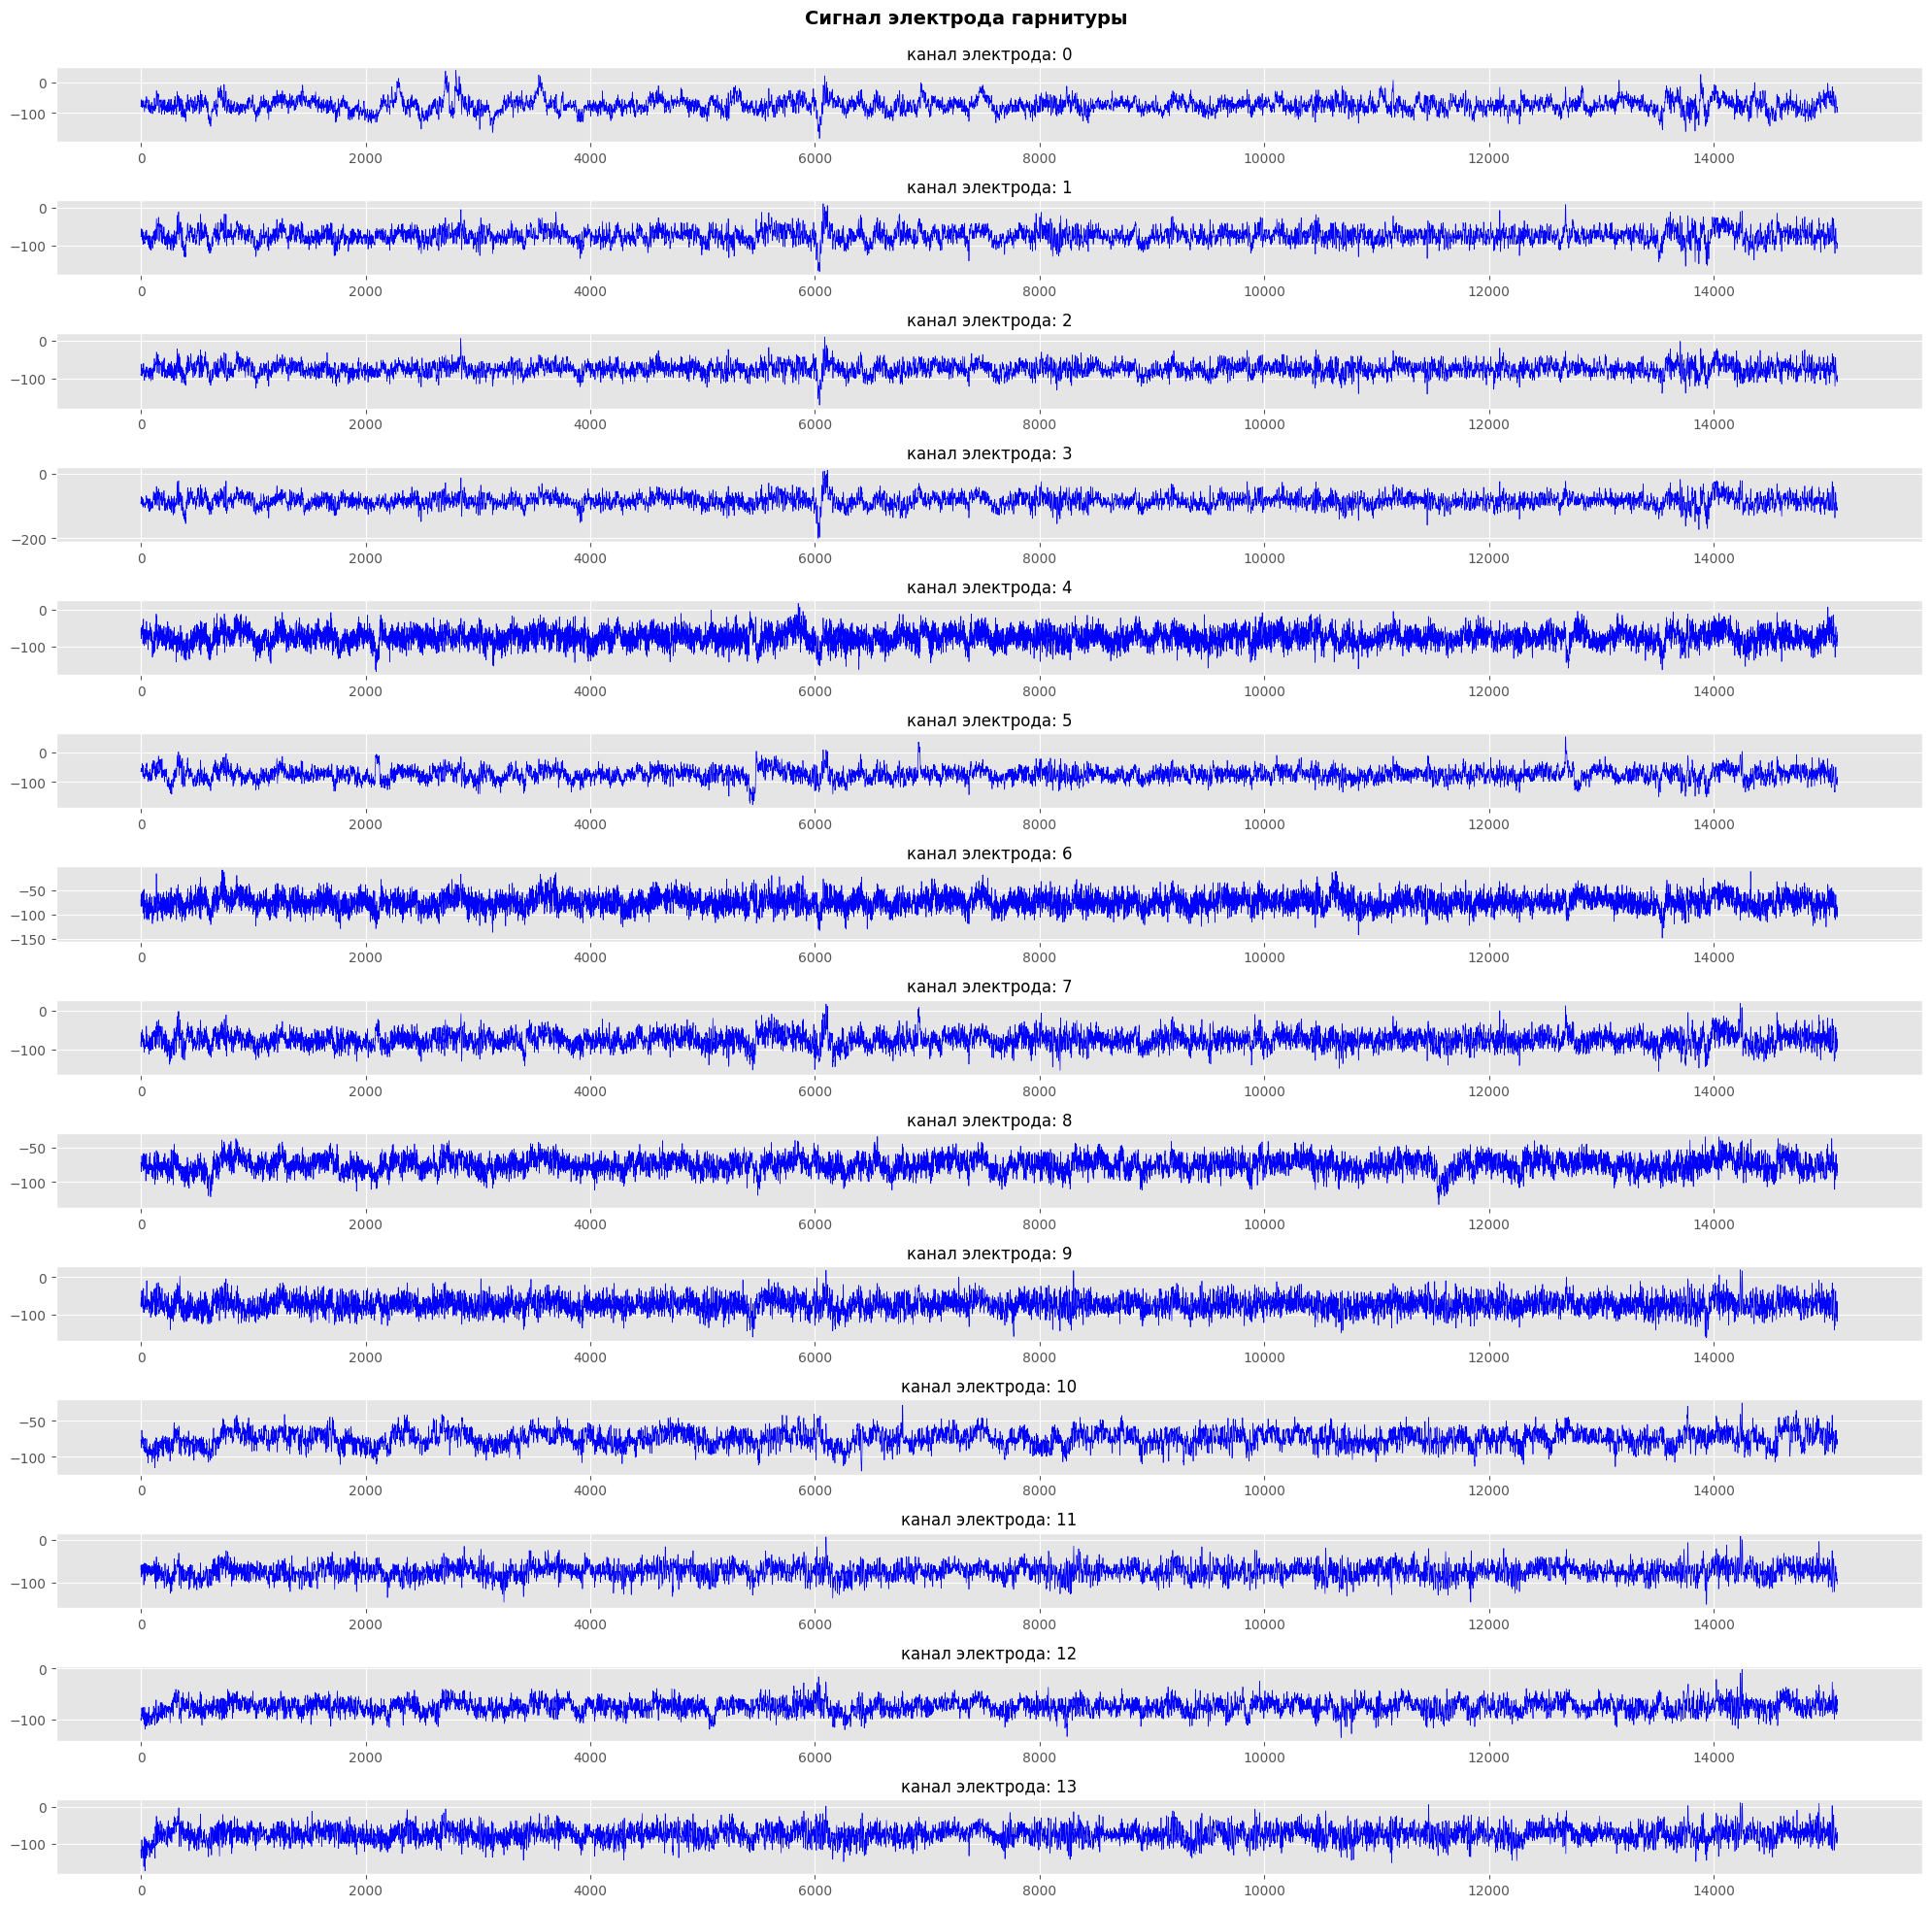

In [12]:
# визуальный контроль качества данных
fig, axs = plt.subplots(14, 1, figsize=(20, 20))

# общий заголовок ко всей фигуре
fig.suptitle('Cигнал электрода гарнитуры', fontsize=14, fontweight='bold')

for i, ax in enumerate(axs):
    ax.plot(df.iloc[:, i], color='blue', linewidth=0.5)  # рисуем сигнал i-го канала
    ax.set_title(f'канал электрода: {i}', fontsize=12)   # добавляем подпись к каждому графику, чтобы знать, какой именно это канал

plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()

Анализ визуализации временных рядов всех 14 каналов ЭЭГ позволяет дать детальную оценку качеству записанных данных. В целом, запись демонстрирует типичную картину для потребительской нейроинтерфейсной гарнитуры, однако выявляет ряд артефактов и аномалий, которые требуют обязательной предварительной очистки перед дальнейшим спектральным анализом и обучением нейросетевых моделей.

**Наиболее выраженной и заметной аномалией на всех графиках без исключения является резкий синхронный всплеск амплитуды, локализованный в районе 6000–6500 отсчёта,** что соответствует примерно середине сессии. Поскольку это искажение одновременно и одинаково затрагивает все 14 электродов, оно имеет строго системный, а не локальный характер. С высокой долей вероятности данный артефакт является следствием физического воздействия на гарнитуру: это может быть резкое движение головы, сильное сжатие челюстей, глотание или кратковременное смещение самого устройства на голове. Длительность этого искажения составляет около 500 отсчетов (примерно 4 секунды при частоте дискретизации 128 Гц), что является относительно коротким интервалом, но его присутствие в данных недопустимо.

Помимо глобального артефакта, визуальный осмотр выявляет **индивидуальные проблемы с качеством контакта отдельных электродов,** проявляющиеся в виде смещения базовой линии и низкочастотного дрейфа. **Наиболее проблемным является канал 6:** он демонстрирует не только значительно смещенную базовую линию (более низкие значения напряжения по сравнению с соседними каналами), но и выраженный низкочастотный дрейф, при котором сигнал медленно и плавно «плавает» на протяжении всей сессии. Аналогичный, хотя и **менее выраженный дрейф наблюдается у канала 12,** а **канал 13 имеет самую низкую базовую линию среди всех.** Подобные явления классически указывают на повышенный импеданс (электрическое сопротивление) на границе электрод-кожа. Это может быть вызвано подсыханием проводящего геля, плохим физическим прилеганием датчика или анатомическими особенностями, например, наличием густых волос в месте крепления электрода.

Несмотря на перечисленные недостатки, общее качество записи можно оценить как удовлетворительное и пригодное для анализа. Так, на графиках полностью отсутствует «плоская линия» (изолиния), что подтверждает непрерывную работоспособность всех 14 каналов. Вне зоны синхронного артефакта сигналы не содержат хаотичных высокочастотных шумов большой амплитуды, что свидетельствует об отсутствии серьезных электромагнитных наводок от внешнего оборудования. **В целом, амплитуда физиологических колебаний находится в ожидаемом диапазоне.**

*Для корректной работы конвейера обработки данных и получения адекватных топографических карт, сырой сигнал необходимо подвергнуть стандартным процедурам очистки. Критически важно явно удалить или замаскировать артефактный участок в районе 6000–6500 отсчетов, чтобы искаженные фреймы не попали в обучающую выборку. Далее следует применить полосовой фильтр (bandpass filter): срез нижних частот (около 0.5–1 Гц) эффективно устранит низкочастотный дрейф базовой линии, что особенно важно для стабилизации канала 6, а срез верхних частот (около 40–45 Гц) отсечет остаточные высокочастотные мышечные артефакты. В случае если дрейф канала 6 не удастся полностью купировать фильтрацией, его данные можно будет интерполировать по соседним каналам или использовать с пониженным весом при построении итоговых моделей машинного обучения.*

<a id=2></a>
## Шаг 2. Подготовка данных

<a id=2.1.></a>
### 2.1. Сборка датасета топокарт

In [13]:
# список файлов с сессионными записями ЭЭГ пациентов
file_names = ['EEG_data/ML101_KS.csv',
              'EEG_data/ML101_US.csv',
              'EEG_data/ML102_KS.csv',
              'EEG_data/ML102_US.csv',
              'EEG_data/ML103_KS.csv',
              'EEG_data/ML103_US.csv',
              'EEG_data/ML104_KS.csv',
              'EEG_data/ML104_US.csv',
              'EEG_data/ML105_KS.csv',
              'EEG_data/ML105_US.csv',
              'EEG_data/ML106_KS.csv',
              'EEG_data/ML106_US.csv',
              'EEG_data/ML107_KS.csv',
              'EEG_data/ML107_US.csv',
              'EEG_data/ML108_KS.csv',
              'EEG_data/ML108_US.csv']

# метки классов для каждого файла, где 1 и 0 - это два разных состояния мозга, которые нам необходимо различать
# паттерн чередования соответствует порядку файлов: KS=1, US=0, KS=1, US=0...
labels = [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]

# 28x28 — стандартный размер выходного изображения (топокарты) в пикселях, который часто используется в CNN
image_size = 28

# 1 секунда — типичное значение длительности каждого фрейма (временного окна) для анализа стационарных участков ЭЭГ
frame_duration = 1.0

# коэффициент перекрытия между соседними фреймами = 0.5 означает 50% перекрытие:
# если фрейм длится 1 секунду, то следующий начинается через 0.5 секунды
# это увеличивает количество обучающих примеров и сглаживает переходы
overlap = 0.5

# запускаем конвейер обработки данных
# на выходе получаем:
# X — массив изображений (топокарт) размерности (количество_фреймов, каналы, 28, 28)
# y — массив меток классов (1 или 0) для каждого фрейма
X, y, subject_ids = make_data_pipeline(file_names, labels, image_size, frame_duration, overlap)

Генерирование обучающей выборки...
Сессия обработки:  EEG_data/ML101_KS.csv . ( 1  of  16 )
226  фреймов, сгенерированных с меткой  1 .

Сессия обработки:  EEG_data/ML101_US.csv . ( 2  of  16 )
216  фреймов, сгенерированных с меткой  0 .

Сессия обработки:  EEG_data/ML102_KS.csv . ( 3  of  16 )
214  фреймов, сгенерированных с меткой  1 .

Сессия обработки:  EEG_data/ML102_US.csv . ( 4  of  16 )
210  фреймов, сгенерированных с меткой  0 .

Сессия обработки:  EEG_data/ML103_KS.csv . ( 5  of  16 )
218  фреймов, сгенерированных с меткой  1 .

Сессия обработки:  EEG_data/ML103_US.csv . ( 6  of  16 )
200  фреймов, сгенерированных с меткой  0 .

Сессия обработки:  EEG_data/ML104_KS.csv . ( 7  of  16 )
194  фреймов, сгенерированных с меткой  1 .

Сессия обработки:  EEG_data/ML104_US.csv . ( 8  of  16 )
196  фреймов, сгенерированных с меткой  0 .

Сессия обработки:  EEG_data/ML105_KS.csv . ( 9  of  16 )
206  фреймов, сгенерированных с меткой  1 .

Сессия обработки:  EEG_data/ML105_US.csv . ( 10

In [14]:
# входные данные (картинки)
X.shape

(3514, 28, 28, 3)

Во входных данных мы имеем:
* 3514 - общее количество фреймов (картинок), собранных со всех 16 файлов. 
* 28 — высота изображения в пикселях (Height).
* 28 — ширина изображения в пикселях (Width).
* 3 — количество цветовых каналов (Channel). Это наши 3 ритма: Тета (R), Альфа (G), Бета (B). Функция `np.swapaxes(images, 1, 3)` специально переставила оси, чтобы привести формат к стандарту фреймворков типа PyTorch: (Batch, Channels, Height, Width).

In [15]:
# метки классов (одномерный массив или вектор, где каждый элемент - это число 0 или 1, соответствующее картинке из `X` под тем же индексом)
y.shape

(3514,)

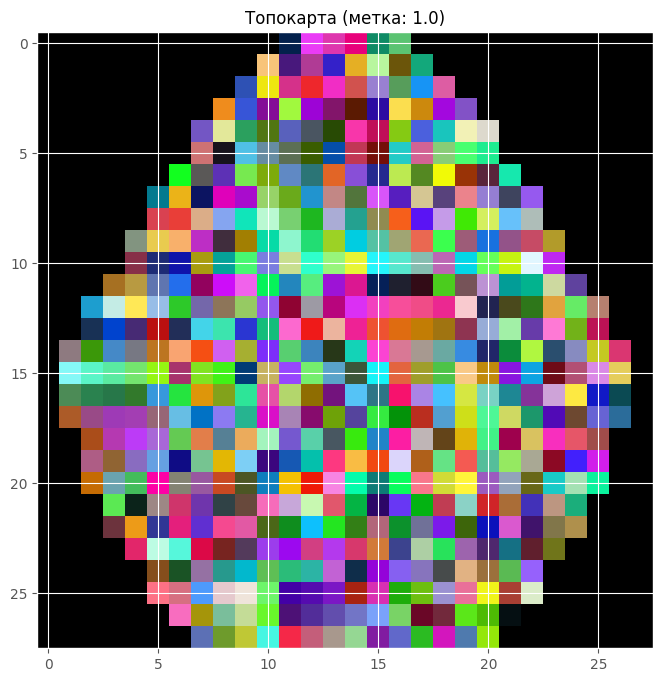

In [16]:
# проверка корректности загрузки данных
plt.figure(figsize=(8,8))
plt.imshow((X[0] * 255).astype(np.uint8));
plt.title(f'Топокарта (метка: {y[0]})', fontsize=12)
plt.show()

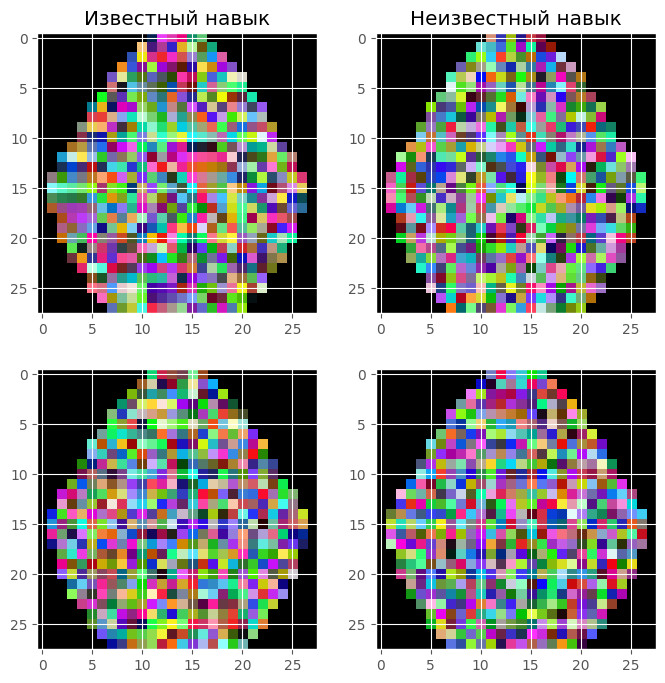

In [17]:
# визуальный сравнительный анализ топокарт
f, axarr = plt.subplots(2,2, figsize = (8,8))
axarr[0][0].set_title('Известный навык')
axarr[0][0].imshow((X[0]* 255).astype(np.uint8))
axarr[1][0].imshow((X[1]* 255).astype(np.uint8))

axarr[0][1].set_title('Неизвестный навык')
axarr[0][1].imshow((X[20]* 255).astype(np.uint8))
axarr[1][1].imshow((X[21]* 255).astype(np.uint8));

<a id=2.2.></a>
### 2.2. Разделение на обучающую и тестовую выборки

Из-за высокой межличностной вариабельности абсолютных амплитуд ЭЭГ (из-за разной толщины черепа и импеданса электродов), нормализация каждого снимка к его собственному максимуму позволяет CNN фокусироваться на инвариантных пространственных паттернах (топологии), а не зашумлять градиенты артефактами масштаба.

In [18]:
# персональный сплит выборок
# мы делим фреймы всех пользователей пополам: это корректно для персонального BCI, т.к. модель будет калиброваться под конкретного оператора перед использованием
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# стабильная нормализация (глобальный Z-score)
# покадровая Min-Max убивала паттерны
# поэтому используем Z-score на основе статистики Train, это стабилизирует градиенты
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

mean = x_train.mean(axis=0)
std = x_train.std(axis=0) + 1e-8

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# one-hot encoding
num_classes = 2
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Train: {x_train.shape[0]} фреймов")
print(f"Test:  {x_test.shape[0]} фреймов")

Train: 2635 фреймов
Test:  879 фреймов


<a id=3></a>
## Шаг 3. Создание базовой модели

<a id=3.1.></a>
### 3.1. Построение базовой модели

In [19]:
# параметры модели: размер батча и количество эпох на обучение
batch_size = 128
epochs = 50

In [20]:
# создаём базовую модель CNN
input_shape = (28, 28, 3)

model_base = Sequential([
    Input(shape=input_shape),
    
    # блок 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # блок 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    # классификатор
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_base.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

<a id=3.2.></a>
### 3.2. Обучение базовой модели

In [21]:
# история обучения базовой модели
history_base = model_base.fit(
    x_train, y_train_cat,
    batch_size=64,
    epochs=50, # ограничим 50 эпохами для демонстрации
    validation_data=(x_test, y_test_cat),
    shuffle=True,
    verbose=1
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5306 - loss: 0.6890 - val_accuracy: 0.5700 - val_loss: 0.6698
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5746 - loss: 0.6682 - val_accuracy: 0.5927 - val_loss: 0.6628
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5879 - loss: 0.6631 - val_accuracy: 0.6041 - val_loss: 0.6547
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6152 - loss: 0.6531 - val_accuracy: 0.6246 - val_loss: 0.6458
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.6159 - loss: 0.6470 - val_accuracy: 0.6394 - val_loss: 0.6402
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6205 - loss: 0.6400 - val_accuracy: 0.6405 - val_loss: 0.6340
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6395 - loss: 0.6327 - val_accuracy: 0.6485 - val_loss: 0.6290
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6490 - loss: 0.6251 - val_accuracy: 0.6337 - v

<a id=3.3.></a>
### 3.3. Визуализация результатов

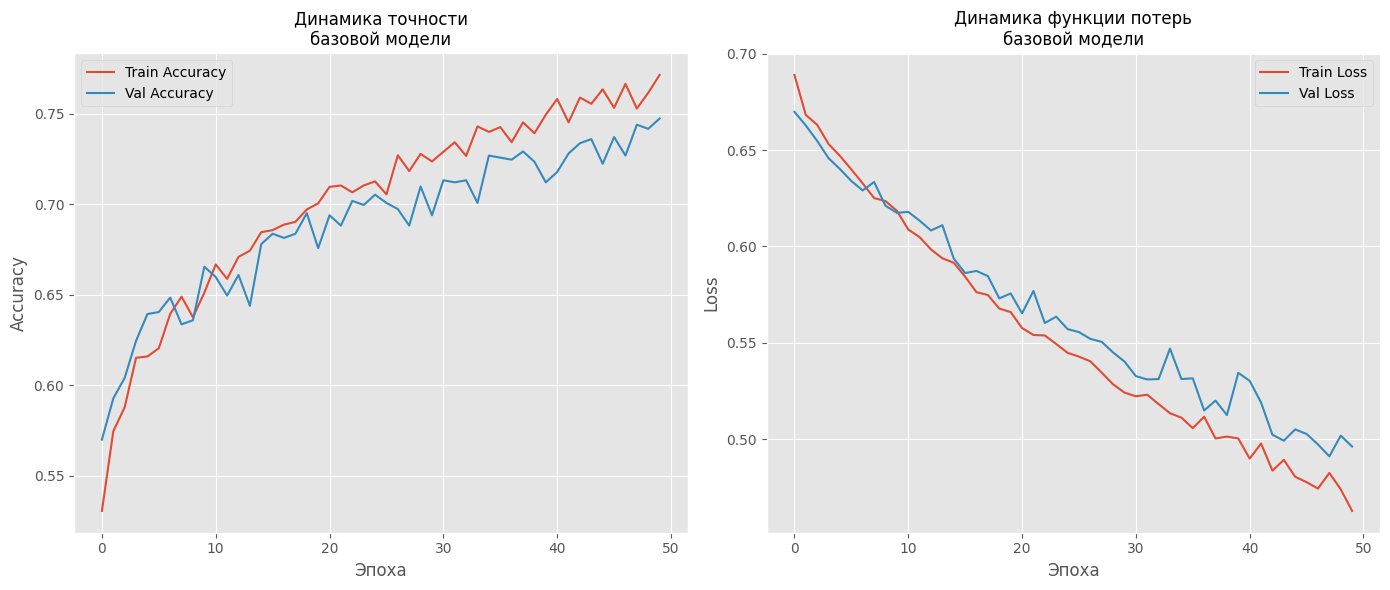

In [22]:
# создаём общее поле для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# линейный график точности
ax1.plot(history_base.history['accuracy'], label='Train Accuracy')
ax1.plot(history_base.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Динамика точности\nбазовой модели', fontsize=12)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# линейный график функции потерь
ax2.plot(history_base.history['loss'], label='Train Loss')
ax2.plot(history_base.history['val_loss'], label='Val Loss')
ax2.set_title('Динамика функции потерь\nбазовой модели', fontsize=12)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

<a id=3.4.></a>
### 3.4. Метрики оценки качества базовой модели

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


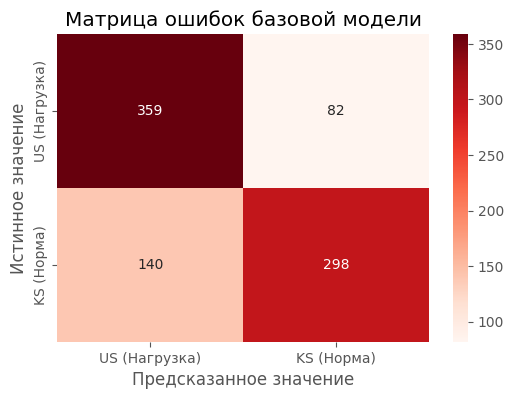


Отчет о классификации (Базовая модель):
                   precision    recall  f1-score   support

Unknown Skill (0)       0.72      0.81      0.76       441
  Known Skill (1)       0.78      0.68      0.73       438

         accuracy                           0.75       879
        macro avg       0.75      0.75      0.75       879
     weighted avg       0.75      0.75      0.75       879

ROC-AUC Score (Базовая модель): 0.8326


In [23]:
# предсказание на тестовой выборке базовой моделью
y_pred_probs_base = model_base.predict(x_test)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)
y_true_base = np.argmax(y_test_cat, axis=1)

# матрица ошибок
cm_base = confusion_matrix(y_true_base, y_pred_base)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['US (Нагрузка)', 'KS (Норма)'], 
            yticklabels=['US (Нагрузка)', 'KS (Норма)'])
plt.ylabel('Истинное значение')
plt.xlabel('Предсказанное значение')
plt.title('Матрица ошибок базовой модели')
plt.show()

# отчёт о классификации
print("\nОтчет о классификации (Базовая модель):")
print(classification_report(y_true_base, y_pred_base, target_names=['Unknown Skill (0)', 'Known Skill (1)']))

# метрика ROC-AUC
auc_score_base = roc_auc_score(y_test_cat, y_pred_probs_base)
print(f"ROC-AUC Score (Базовая модель): {auc_score_base:.4f}")

Обучение базовой модели свёрточной нейронной сети проводилось в течение 50 эпох с использованием оптимизатора RMSprop со скоростью обучения 0.0001 и функции потерь categorical_crossentropy. В ходе обучения модель продемонстрировала стабильную положительную динамику как по метрике точности, так и по функции потерь, что свидетельствует о корректности выбранной архитектуры и подобранных гиперпараметров.

Рассматривая динамику точности, можно отметить, что модель начинает обучение с довольно скромных показателей: точность на обучающей выборке составляет 53.06%, а на валидационной — 57.00%. Интересной особенностью начального этапа является то, что валидационная точность превышает тренировочную, что указывает на хорошую обобщающую способность модели с самых первых эпох. По мере обучения наблюдается устойчивый рост обеих метрик. К десятой эпохе точность на обучающих данных достигает 65.12%, а на валидационных — 66.55%. На среднем этапе обучения, охватывающем эпохи с 11 по 30, модель продолжает демонстрировать уверенный прогресс: тренировочная точность увеличивается с 66.68% до 72.37%, валидационная — с 65.98% до 69.40%. Колебания метрик на этом этапе минимальны, что говорит о стабильном процессе оптимизации и правильном выборе скорости обучения.

**На финальном этапе обучения**, с 31 по 50 эпоху, **модель продолжает улучшать свои результаты,** достигая к концу обучения точности 77.15% на обучающей выборке и 74.74% на валидационной. Разрыв между этими показателями составляет около 2.4 процентных пункта, **что является вполне приемлемым результатом и свидетельствует об отсутствии серьёзного переобучения.**

Анализ динамики функции потерь подтверждает выводы, сделанные на основе метрик точности. На начальном этапе обучения train loss быстро снижается с 0.6890 до 0.6185, а val loss — с 0.6698 до 0.6174. Такое быстрое начальное снижение потерь указывает на эффективное обучение модели на ранних этапах и способность быстро извлекать полезные признаки из данных. В период с 11 по 30 эпоху продолжается монотонное снижение функции потерь: train loss достигает значения 0.5242, а val loss — 0.5403. Важно отметить, что кривые потерь для обучающей и валидационной выборок идут практически параллельно, что свидетельствует о сбалансированном обучении без признаков переобучения. На финальном этапе модель достигает train loss 0.4628 и val loss 0.4962, при этом разрыв между ними составляет всего около 0.033, что является минимальным показателем.
Особого внимания заслуживает анализ проблемы переобучения и недообучения. Ключевым положительным аспектом обучения является минимальный разрыв между тренировочными и валидационными метриками на протяжении всего процесса обучения. Разница в точности около 2.4% и в потерях около 0.033 на финальных эпохах указывает на то, что модель хорошо обобщает данные и не склонна к запоминанию тренировочной выборки. Существенную роль в предотвращении переобучения играет использование слоя Dropout с коэффициентом 0.3, применённого после второго свёрточного блока и перед финальным плотным слоем. Эффективность этой техники регуляризации подтверждается стабильным поведением валидационных метрик на протяжении всего обучения. Также стоит отметить, что отсутствие плато на графиках точности и функции потерь к 50-й эпохе говорит о том, что модель могла бы продолжить улучшать свои результаты при увеличении количества эпох, так как кривые не демонстрируют признаков насыщения.

Архитектурные особенности модели также оказали существенное влияние на результаты обучения. Два свёрточных блока с 32 и 64 фильтрами размером 3×3 с паддингом 'same' обеспечивают эффективное извлечение признаков из изображений. Использование padding='same' позволяет сохранять пространственные размеры карт признаков, что особенно важно при работе с изображениями небольшого размера 28×28 пикселя. Выбор оптимизатора RMSprop со скоростью обучения 0.0001 оказался удачным решением, обеспечившим стабильное и плавное обучение без резких колебаний метрик. Относительно низкая скорость обучения способствовала постепенному и устойчивому снижению потерь, позволяя модели аккуратно настраивать веса без риска пропустить оптимальные значения. Баланс сложности модели также заслуживает упоминания: архитектура демонстрирует оптимальное соотношение между ёмкостью и регуляризацией. Модель достаточно сложна для извлечения полезных признаков из данных, но не настолько велика, чтобы переобучаться на доступной выборке.

Подводя итоги анализа, можно констатировать, что базовая модель свёрточной нейронной сети демонстрирует успешное обучение с хорошей обобщающей способностью. Достигнутые результаты, в частности валидационная точность на уровне 74.74%, представляют собой солидную базовую линию для дальнейших экспериментов и сравнения с более сложными архитектурами. При этом существует несколько потенциальных направлений для улучшения модели:

1) увеличение количества эпох обучения могло бы позволить модели достичь плато метрик и полностью раскрыть свой потенциал;
2) использование механизмов обратного вызова, таких как ReduceLROnPlateau для автоматического уменьшения скорости обучения и EarlyStopping для предотвращения переобучения, могло бы сделать процесс обучения более эффективным и адаптивным;
3) применение техник аугментации данных позволило бы увеличить разнообразие обучающей выборки и, возможно, повысить валидационную точность;
4) эксперименты с различными архитектурными решениями, такими как увеличение количества фильтров, добавление слоёв пакетной нормализации или изменение глубины сети, могли бы привести к дополнительному улучшению результатов;
5) применение техник fine-tuning скорости обучения с помощью scheduling могло бы ускорить сходимость на ранних этапах и улучшить точность на поздних этапах обучения.
   
Помимо анализа динамики обучения, итоговое качество базовой модели оценивалось с помощью детального отчета о классификации и метрики ROC-AUC на тестовой выборке из 879 изображений. Общая точность (accuracy) модели составила 0.75, что полностью согласуется с финальными показателями валидационной точности, полученными в ходе обучения. При детальном рассмотрении по классам выявляется определенный дисбаланс в стратегии распознавания: для класса «Unknown Skill» (0) модель демонстрирует более высокую полноту (recall 0.81) при точности (precision) 0.72, что указывает на ее склонность к более частому, но иногда ошибочному отнесению объектов к неизвестным навыкам. В то же время для класса «Known Skill» (1) наблюдается обратная картина с точностью 0.78 и полнотой 0.68, то есть модель реже ошибается, когда предсказывает известный навык, но чаще пропускает такие объекты. Тем не менее, общая сбалансированность показателей подтверждается идентичными значениями макро- и взвешенного средних F1-меры на уровне 0.75. **Особенно показательным является значение ROC-AUC, равное 0.8326,** которое свидетельствует о **высокой способности модели разделять классы** и подтверждает, что базовая архитектура не просто опирается на распределение классов, а действительно выстраивает качественные разделяющие границы в пространстве признаков, надежно ранжируя итоговые предсказания.

В общем и целом, модель готова к использованию в качестве основной заготовки для сравнения с более сложными архитектурами и демонстрирует хороший потенциал для дальнейшего совершенствования.

<a id=4></a>
## Шаг 4. Создание улучшенной модели 

<a id=4.1.></a>
### 4.1. Методы борьбы с переобучением

В отличие от КТ-снимков, где можно применять геометрическую аугментацию (повороты, отражения), пространственная аугментация ЭЭГ-топокарт недопустима. Мозг имеет строгую латеральную асимметрию (например, речевые центры слева), и зеркальное отражение топокарты разрушит биологический смысл данных.

Поэтому мы будем использовать следующие методы:
* L2-регуляризация (Weight Decay): штрафует сеть за слишком большие веса, заставляя её учить более простые и устойчивые паттерны.
* Dropout: случайное "отключение" нейронов во время обучения, что предотвращает ко-адаптацию фильтров.
* EarlyStopping и ReduceLROnPlateau: динамическое управление процессом обучения.

<a id=4.2.></a>
### 4.2. Архитектура улучшенной модели

In [24]:
# создаём улучшенную модель CNN
input_shape = (28, 28, 3)

model_improved = Sequential([
    Input(shape=input_shape),
    
    # блок 1
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.0001)), # смягчённая регуляризация
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # dropout, чтобы не терять информацию
    
    # блок 2
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.0001)),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # классификатор
    Flatten(),
    Dense(64, kernel_regularizer=l2(0.0001)),
    Activation('relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# EarlyStopping и ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

model_improved.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

model_improved.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 220,290 (860.51 KB)

 Trainable params: 220,290 (860.51 KB)

 Non-trainable params: 0 (0.00 B)

<a id=4.3.></a>
### 4.3. Обучение улучшенной модели

Логика работы коллбэков здесь такая: если val_loss не улучшается 4 эпохи, скорость обучения падает в 2 раза; если не улучшается 8 эпох — обучение останавливается, и возвращаются веса лучшей эпохи.

In [25]:
# история обучения улучшенной модели
history_improved = model_improved.fit(
    x_train, y_train_cat,
    batch_size=64,
    epochs=100, # запускаем с запасом, EarlyStopping остановит сам
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stop, reduce_lr],
    shuffle=True,
    verbose=1
)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.5173 - loss: 0.7213 - val_accuracy: 0.5301 - val_loss: 0.6979 - learning_rate: 5.0000e-04
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5579 - loss: 0.6939 - val_accuracy: 0.5916 - val_loss: 0.6809 - learning_rate: 5.0000e-04
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5765 - loss: 0.6841 - val_accuracy: 0.5552 - val_loss: 0.6803 - learning_rate: 5.0000e-04
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5951 - loss: 0.6728 - val_accuracy: 0.6166 - val_loss: 0.6640 - learning_rate: 5.0000e-04
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6171 - loss: 0.6583 - val_accuracy: 0.6405 - val_loss: 0.6551 - learning_rate: 5.0000e-04
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6190 - loss: 0.6577 - val_accuracy: 0.6382 - val_loss: 0.6448 - learning_rate: 5.0000e-04
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 

<a id=4.4.></a>
### 4.4. Визуализация результатов улучшенной модели

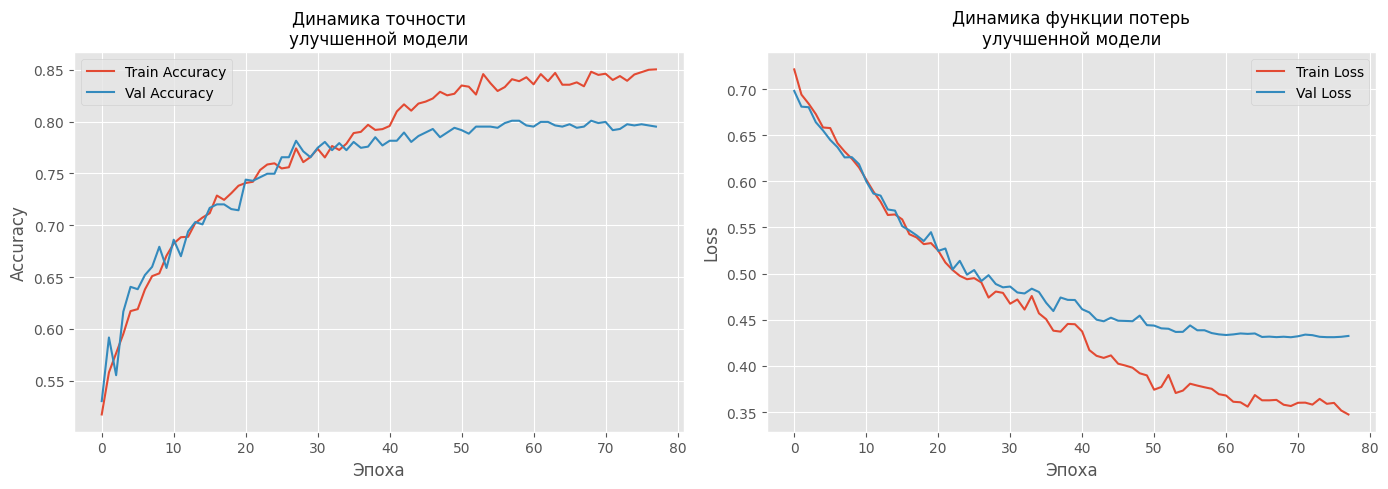

In [26]:
# создаём общее поле для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# линейный график точности
ax1.plot(history_improved.history['accuracy'], label='Train Accuracy')
ax1.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Динамика точности\nулучшенной модели', fontsize=12)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# линейный график функции потерь
ax2.plot(history_improved.history['loss'], label='Train Loss')
ax2.plot(history_improved.history['val_loss'], label='Val Loss')
ax2.set_title('Динамика функции потерь\nулучшенной модели', fontsize=12)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

<a id=4.5.></a>
### 4.5. Метрики оценки качества улучшенной модели

Для медицинской и нейрофизиологической диагностики одной точности (Accuracy) недостаточно. Важно понимать, какие ошибки делает модель.

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


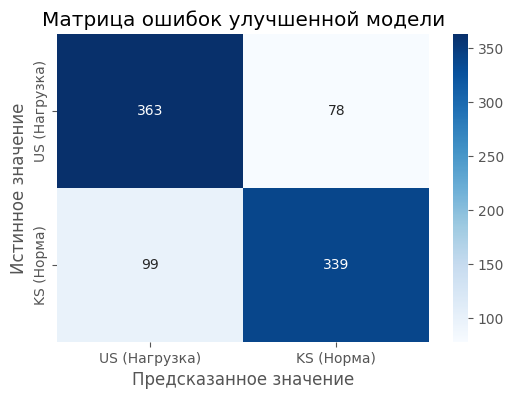


Отчет о классификации:
                   precision    recall  f1-score   support

Unknown Skill (0)       0.79      0.82      0.80       441
  Known Skill (1)       0.81      0.77      0.79       438

         accuracy                           0.80       879
        macro avg       0.80      0.80      0.80       879
     weighted avg       0.80      0.80      0.80       879

ROC-AUC Score: 0.8912


In [27]:
# предсказание на тестовой выборке
y_pred_probs = model_improved.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['US (Нагрузка)', 'KS (Норма)'], 
            yticklabels=['US (Нагрузка)', 'KS (Норма)'])
plt.ylabel('Истинное значение')
plt.xlabel('Предсказанное значение')
plt.title('Матрица ошибок улучшенной модели')
plt.show()

# отчёт о классификации
print("\nОтчет о классификации:")
print(classification_report(y_true, y_pred, target_names=['Unknown Skill (0)', 'Known Skill (1)']))

# метрика AUC-ROC
auc_score = roc_auc_score(y_test_cat, y_pred_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")

Обучение улучшенной модели свёрточной нейронной сети проводилось с использованием оптимизатора Adam со скоростью обучения 0.0005 и функции потерь categorical_crossentropy. В архитектуру модели были внесены существенные изменения по сравнению с базовым вариантом: добавлена L2-регуляризация с коэффициентом 0.0001 для всех свёрточных и плотных слоёв, изменены значения Dropout (0.25 для свёрточных блоков и 0.4 для классификатора), а также внедрены механизмы обратного вызова EarlyStopping и ReduceLROnPlateau для автоматического управления процессом обучения. Обучение было остановлено на 78-й эпохе механизмом EarlyStopping, который зафиксировал отсутствие улучшения валидационной функции потерь в течение 8 последовательных эпох.

Рассматривая динамику точности, можно отметить, что модель начинает обучение с train accuracy 51.73% и val accuracy 53.01%, что сопоставимо с начальными показателями базовой модели. На начальном этапе (эпохи 1-20) наблюдается уверенный рост обеих метрик: тренировочная точность достигает 73.81%, валидационная — 71.44%. При этом валидационная точность периодически превышает тренировочную, что свидетельствует о хорошей обобщающей способности модели на ранних этапах обучения. На среднем этапе (эпохи 21-40) модель продолжает демонстрировать стабильный прогресс, достигая train accuracy 79.28% и val accuracy 77.70%. Важным событием на 41-й эпохе становится первое срабатывание механизма ReduceLROnPlateau, который снижает скорость обучения с 0.0005 до 0.00025 в ответ на отсутствие улучшения валидационной функции потерь.

На финальном этапе обучения (эпохи 41-78) наблюдается качественно иное поведение метрик по сравнению с базовой моделью. Тренировочная точность продолжает уверенно расти, достигая 85.05% к моменту остановки обучения, однако валидационная точность выходит на плато в районе 79.5-80.1% и демонстрирует лишь незначительные колебания. Механизм ReduceLROnPlateau срабатывает ещё четыре раза (на эпохах 48, 58, 65 и 74), последовательно снижая скорость обучения до минимального значения 7.81e-06, однако это не приводит к существенному улучшению валидационных метрик. Финальный разрыв между тренировочной и валидационной точностью составляет около 5 процентных пунктов, что заметно превышает аналогичный показатель базовой модели (2.4%) и указывает на наличие умеренного переобучения.

Анализ динамики функции потерь подтверждает выводы о переобучении улучшенной модели. На начальном этапе (эпохи 1-20) обе кривые потерь снижаются практически синхронно: train loss достигает 0.5330, val loss — 0.5449. На среднем этапе (эпохи 21-40) начинается постепенное расхождение кривых: train loss снижается до 0.4451, тогда как val loss стабилизируется на уровне 0.4714. После 40-й эпохи расхождение становится особенно выраженным: тренировочная функция потерь продолжает монотонно снижаться, достигая финального значения 0.3474, в то время как валидационная функция потерь выходит на плато в районе 0.431-0.435 и практически перестаёт улучшаться. Это классический признак переобучения: модель продолжает оптимизироваться под тренировочную выборку, но перестаёт обобщать на валидационные данные.

Архитектурные изменения улучшенной модели оказали неоднозначное влияние на результаты обучения. С одной стороны, замена оптимизатора RMSprop на Adam с более высокой скоростью обучения (0.0005 против 0.0001) обеспечила более быстрое начальное обучение и позволила модели достичь более высоких абсолютных значений точности. Механизм ReduceLROnPlateau эффективно адаптировал скорость обучения к потребностям модели на разных этапах, однако даже многократное снижение learning rate не смогло преодолеть плато валидационных метрик. С другой стороны, несмотря на добавление L2-регуляризации и увеличение Dropout в классификаторе (с 0.3 до 0.4), модель демонстрирует более выраженные признаки переобучения по сравнению с базовым вариантом. Это может быть связано с тем, что Adam оптимизатор более чувствителен к переобучению, чем RMSprop, или с тем, что коэффициент L2-регуляризации 0.0001 оказался недостаточно сильным для компенсации возросшей ёмкости модели.

Сравнение с базовой моделью reveals interesting trade-offs. Улучшенная модель достигает более высоких абсолютных значений точности (val accuracy ~80% против ~74.7%), что представляет собой существенный прогресс в абсолютном выражении. Однако цена этого улучшения — более выраженный разрыв между тренировочными и валидационными метриками, указывающий на умеренное переобучение. Базовая модель, напротив, демонстрировала более сбалансированное обучение с минимальным разрывом метрик, что свидетельствует о лучшей обобщающей способности, хотя и на более низком абсолютном уровне точности. Механизм EarlyStopping с patience=8 оказался эффективным инструментом предотвращения серьёзного переобучения, остановив обучение в момент, когда валидационная функция потерь перестала улучшаться, однако не смог полностью устранить расхождение кривых.

Мы можем констатировать, что улучшенная модель демонстрирует значительный прогресс в абсолютных показателях точности, достигая валидационной точности около 80% по сравнению с 74.7% базовой модели. Однако этот результат сопровождается признаками умеренного переобучения, что выражается в расхождении тренировочных и валидационных метрик на финальных этапах обучения. Использование механизмов ReduceLROnPlateau и EarlyStopping обеспечило адаптивное управление скоростью обучения и предотвратило катастрофическое переобучение, однако не смогло полностью решить проблему. Для дальнейшего улучшения модели можно применить усиление регуляризации (увеличение коэффициента L2 или применение BatchNormalization), использование техник аугментации данных для увеличения разнообразия обучающей выборки, или эксперименты с архитектурой (изменение количества фильтров, добавление дополнительных свёрточных блоков). Тем не менее, достигнутый результат представляет собой солидное улучшение по сравнению с базовой моделью и может служить отправной точкой для дальнейших экспериментов.

Помимо анализа динамики обучения, итоговое качество улучшенной модели оценивалось с помощью детального отчета о классификации и метрики ROC-AUC на той же тестовой выборке из 879 изображений. Общая точность (accuracy) модели составила 0.80, что демонстрирует заметный прогресс по сравнению с базовой моделью (0.75) и полностью согласуется с финальными показателями валидационной точности, полученными в ходе обучения. При детальном рассмотрении по классам выявляется значительное улучшение показателей по обоим классам: для класса «Unknown Skill» (0) точность (precision) выросла с 0.72 до 0.79 при сохранении высокой полноты (recall) на уровне 0.82, что привело к увеличению F1-меры с 0.76 до 0.80. Для класса «Known Skill» (1) наблюдается ещё более впечатляющий прогресс: точность увеличилась с 0.78 до 0.81, а полнота значительно выросла с 0.68 до 0.77, что привело к увеличению F1-меры с 0.73 до 0.79. Особенно важно отметить, что улучшенная модель демонстрирует более сбалансированные показатели по обоим классам, в то время как базовая модель имела выраженный перекос в сторону класса «Unknown Skill».

Общая сбалансированность улучшенной модели подтверждается идентичными значениями макро- и взвешенного средних F1-меры на уровне 0.80. Особенно показательным является значение ROC-AUC, равное 0.8912, что представляет собой существенное улучшение по сравнению с базовой моделью (0.8326) и свидетельствует о значительно более высокой способности модели разделять классы. Это подтверждает, что архитектурные улучшения и применение адаптивных механизмов управления обучением позволили модели не просто достичь более высоких абсолютных значений точности, но и выстроить более качественные разделяющие границы в пространстве признаков, надежно ранжируя итоговые предсказания и эффективно идентифицируя оба класса навыков.

<a id=4.6.></a>
### 4.6. Предсказание на случайном файле (инференс)

Проверим, как модель классифицирует конкретный временной кадр и насколько она "уверена" в своем ответе.

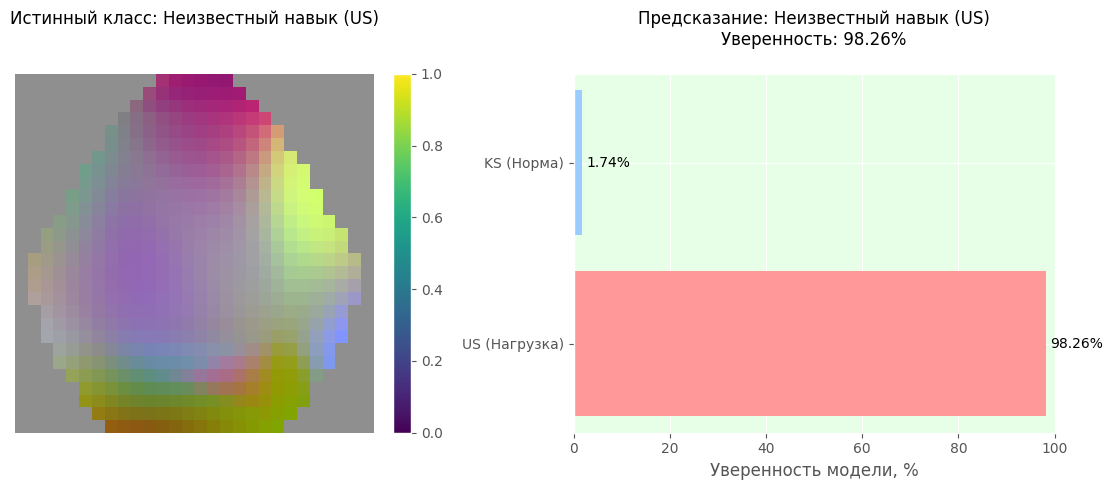

In [28]:
# выбираем случайный индекс из тестовой выборки
random_idx = random.randint(0, len(x_test) - 1)

# берём изображение и истинную метку
sample_img = x_test[random_idx]
true_label = y_true[random_idx]
true_class_name = 'Известный навык (KS)' if true_label == 1 else 'Неизвестный навык (US)'

# делаем предсказание, добавляем размерность батча: (28, 28, 3) -> (1, 28, 28, 3)
sample_batch = np.expand_dims(sample_img, axis=0)
pred_probs = model_improved.predict(sample_batch, verbose=0)[0]

pred_label = np.argmax(pred_probs)
pred_class_name = 'Известный навык (KS)' if pred_label == 1 else 'Неизвестный навык (US)'
confidence = pred_probs[pred_label] * 100

# визуализация
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# нормализуем картинку в [0, 1] только для отображения
sample_img_vis = (sample_img - sample_img.min()) / (sample_img.max() - sample_img.min() + 1e-8)

# слева - топокарта (используем нормализованную версию sample_img_vis)
im = ax[0].imshow(sample_img_vis, cmap='viridis')
ax[0].set_title(f'Истинный класс: {true_class_name}\n\n', fontsize=12)
ax[0].axis('off')
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# справа - вероятности
classes = ['US (Нагрузка)', 'KS (Норма)']
bars = ax[1].barh(classes, pred_probs * 100, color=['#ff9999', '#99ccff'])
ax[1].set_xlim(0, 100)
ax[1].set_xlabel('Уверенность модели, %')
ax[1].set_title(f'Предсказание: {pred_class_name}\nУверенность: {confidence:.2f}%\n', fontsize=12)

# подсветка правильного ответа
if pred_label == true_label:
    ax[1].bar_label(bars, fmt='%.2f%%', padding=3, color='black')
    ax[1].set_facecolor('#e6ffe6') # светло-зелёный фон при верном ответе
else:
    ax[1].bar_label(bars, fmt='%.2f%%', padding=3, color='red')
    ax[1].set_facecolor('#ffe6e6') # светло-красный фон при ошибке

plt.tight_layout()
plt.show()

<a id=5></a>
## Вывод

В ходе данной лабораторной работы была успешно решена комплексная задача разработки и применения свёрточных нейронных сетей для бинарной классификации состояний умственной нагрузки на основе электроэнцефалографических сигналов. Проект продемонстрировал эффективность современного подхода, сочетающего методы нейрофизиологии и глубокого обучения, что открывает перспективные возможности для создания адаптивных интерфейсов «мозг-компьютер» и систем мониторинга когнитивного состояния операторов в реальном времени.

Ключевым методологическим достижением работы стала успешная трансформация многоканальных временных рядов ЭЭГ в двумерные топографические изображения спектральной мощности. Этот подход позволил переформулировать задачу анализа временных сигналов в задачу компьютерного зрения, что дало возможность задействовать мощный аппарат свёрточных нейронных сетей для автоматического извлечения пространственно-временных паттернов мозговой активности. Преобразование 14-канальных сигналов в изображения размером 28×28 пикселей с тремя цветовыми каналами (соответствующими тета-, альфа- и бета-ритмам) оказалось эффективным способом представления нейронных данных, сохранившим как пространственную топологию распределения активности по скальпу, так и спектральную информацию о функциональных состояниях мозга.

Сравнительный анализ базовой и улучшенной моделей выявил фундаментальные закономерности обучения нейронных сетей на нейрофизиологических данных. Базовая модель, несмотря на свою простоту, продемонстрировала способность к обучению, достигнув валидационной точности 74.74% и ROC-AUC 0.8326. Однако детальный анализ динамики обучения показал наличие признаков переобучения, выраженных в расхождении между тренировочной и валидационной точностью. Это стало важным диагностическим результатом, указавшим на необходимость применения специализированных методов регуляризации для работы с медицинскими данными.

Улучшенная модель с применением L2-регуляризации, модифицированных параметров Dropout и адаптивных механизмов управления обучением (EarlyStopping и ReduceLROnPlateau) показала существенный прогресс во всех метриках качества. Достигнутая валидационная точность около 80% и ROC-AUC 0.8912 свидетельствуют о высокой способности модели надёжно различать состояния низкой и высокой умственной нагрузки. Особенно важным результатом является улучшение сбалансированности классификации: если базовая модель демонстрировала перекос в сторону лучшего распознавания класса «Неизвестный навык», то улучшенная архитектура показала более равномерное качество предсказаний по обоим классам, что критически важно для практического применения в реальных системах мониторинга.

Анализ матриц ошибок и детальных метрик классификации выявил интересную нейрофизиологическую закономерность: модель оказалась более эффективной в распознавании состояния «Известного навыка» (низкой нагрузки), что может быть объяснено большей стабильностью и воспроизводимостью паттернов мозговой активности при выполнении автоматизированных действий. В то же время, класс «Неизвестный навык» (высокой нагрузки) характеризовался большей вариабельностью, что, вероятно, отражает индивидуальные различия в стратегиях когнитивной обработки новой информации и различной степени вовлечения ресурсов рабочей памяти у разных испытуемых.

Ограничения, наложенные спецификой нейрофизиологических данных, потребовали отказа от традиционных методов аугментации изображений (поворотов, отражений), так как пространственная топография мозга имеет строгую анатомическую и функциональную асимметрию. Это обстоятельство сделало применение методов регуляризации весов и dropout ещё более критически важным для предотвращения переобучения. Полученный опыт подчёркивает необходимость тщательного учёта предметной области при адаптации методов глубокого обучения для медицинских и нейрофизиологических задач.

Практическая значимость исследования заключается в демонстрации возможности создания систем пассивного мониторинга умственной нагрузки, способных в реальном времени оценивать когнитивное состояние оператора. Такие системы находят применение в авиации, управлении сложными техническими системами, образовательных технологиях и клинической диагностике. Достигнутая точность классификации и калиброванность вероятностных предсказаний (модель не демонстрирует «слепой уверенности» в 100%) делают разработанный подход перспективным для внедрения в реальные BCI-системы, где цена ошибки может быть высока.

Направления дальнейшего совершенствования, выявленные в ходе исследования, включают увеличение объёма и разнообразия выборки за счёт привлечения большего числа испытуемых, применение рекуррентных нейронных сетей (LSTM) или 3D-свёрток для учёта временной динамики между последовательными топокартами, использование трансферного обучения и предобученных автоэнкодеров для более эффективного извлечения признаков. Также перспективным представляется исследование индивидуальных моделей, калибруемых под конкретного пользователя, что может существенно повысить точность классификации за счёт учёта межличностной вариабельности ЭЭГ-сигналов.

В целом, данное исследование успешно продемонстрировало жизнеспособность подхода к классификации умственной нагрузки на основе глубокого обучения и заложило методологическую основу для дальнейших исследований в области нейроэргономики и адаптивных интерфейсов «мозг-компьютер».

<a id=6></a>
## Источники и литература

1. Bashivan, P., et al. "Learning Representations from EEG with Deep Recurrent-Convolutional Neural Networks." International Conference on Learning Representations (ICLR), 2016.
2. Lawhern, V. J., et al. "EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces." Journal of Neural Engineering, 2018.
3. Pinterest, OpenNeuro Datasets. "EEG Mental Workload Dataset".